In [5]:
# ## 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from collections import namedtuple
import time
from tqdm.auto import tqdm # Import tqdm for progress bars

def do_ple_scan(lines = 1, in_range = None, frequency=None, resolution=None, channel = None):
    """
    fine_scan_range = (
            ple_gui.fit_result[1].best_values['center']
            - ple_gui.fit_result[1].best_values['sigma'] * 3,
            ple_gui.fit_result[1].best_values['center']
            + ple_gui.fit_result[1].best_values['sigma']  * 3
        )
    """
    if channel is not None:
        ple_gui._mw.channel_comboBox.setCurrentText(channel) ## MAY BE MISTAKEN
        # ple_gui._mw.channel_comboBox.setCurrentText('APD4')
    #laser_scanner_logic.scan_ranges["a"]
    if in_range is None:
        ple_gui._mw.actionFull_range.triggered.emit()
    else:
        ple_gui.sigScanSettingsChanged.emit(
            {'range': {ple_gui.scan_axis: in_range}}
        )
    ple_gui._mw.number_of_repeats_SpinBox.setValue(lines)
    ple_gui._mw.number_of_repeats_SpinBox.editingFinished.emit()
    time.sleep(0.5)
    ple_gui._mw.actionToggle_scan.setChecked(True)
    ple_gui.toggle_scan()
    while laser_scanner_logic.module_state()=='locked':
            time.sleep(0.5)
    time.sleep(0.2)
    ple_gui._fit_dockwidget.fit_widget.sigDoFit.emit("TwoLorentz")
    time.sleep(0.2)
    #ple_gui._accumulated_data.mean(axis=0)
    #print(f"Rsquared {ple_gui.fit_result[1].rsquared}")
    #ple_gui.fit_result[1].params["center"].value
    return ple_gui.fit_result[1]

def save_ple(tag, poi_name=None, folder_name = None):
        if folder_name:
            ple_gui._save_folderpath = folder_name
            ple_gui.save_path_widget.currPathLabel.setText(ple_gui._save_folderpath)
        ple_gui.save_path_widget.saveTagLineEdit.setText(
            f"{tag}"
            )
        ple_gui._mw.actionSave.triggered.emit()
def go_to_ple_target(target):
    ple_gui._mw.ple_widget.target_point.setValue(target)
    ple_gui._mw.ple_widget.target_point.sigPositionChangeFinished.emit(target)
    #laser_scanner_logic.set_target_position({"a": target})
    time.sleep(0.5)

In [ ]:
vector_magnet

In [ ]:
vector_magnet.get_field()

In [ ]:
vector_magnet.ramp(field_target= [0.01, 0.05, 0.05])

In [ ]:
B_amplitude = 0.2  # Tesla

# Define the angular resolution of the sweep
theta_steps = 7  # Number of steps from 0 to 90 deg
phi_steps = 12  # Number of steps from 0 to 90 deg

# Create the grid of angles for the first octant (all components positive)
# theta: 0 to pi/2
# phi: 0 to p
thetas = np.linspace(np.pi/2, np.pi/2 - np.pi/10, theta_steps)
phis = np.linspace(0, np.pi/4, phi_steps)

all_field_targets = []

# Iterate through each point on the spherical grid
for phi in phis:
    for theta in thetas:
        # a. Convert spherical to Cartesian coordinates
        By = B_amplitude * np.sin(theta) * np.cos(phi)
        Bx = B_amplitude * np.sin(theta) * np.sin(phi)
        Bz = B_amplitude * np.cos(theta)
        field_target = [Bx, By, Bz]
        all_field_targets.append(field_target)

print(f"Generated {len(all_field_targets)} points in the first octant.")

# ## 3. Prepare Data for Plotting
# Convert the list of points into a NumPy array for easier slicing
points_array = np.array(all_field_targets)

points_array = np.array(all_field_targets)

# Extract X, Y, and Z coordinates
x_coords = points_array[:, 0]
y_coords = points_array[:, 1]
z_coords = points_array[:, 2]

# ## 4. Create the 3D Plot
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
ax.scatter(x_coords, y_coords, z_coords, c='b', marker='o', label='B-Field Target Points')

# Add labels and a title for clarity
ax.set_xlabel('Bx (T)', fontsize=12)
ax.set_ylabel('By (T)', fontsize=12)
ax.set_zlabel('Bz (T)', fontsize=12)
ax.set_title('3D Visualization of Spherical B-Field Grid', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([0, B_amplitude])
ax.set_ylim([0, B_amplitude])
ax.set_zlim([0, B_amplitude])
ax.set_aspect('equal') # This is crucial for a correct aspect ratio

# Add a legend
ax.legend()

# Show the plot
plt.show()
print("Plot displayed.")

In [ ]:
# ## 1. Define Simulation Parameters
# Define the magnetic field amplitude
B_amplitude = 0.2  # Tesla

# Define the angular resolution for the sweep in each plane
num_steps = 150  # Number of points for each 90-degree arc

# ## 2. Generate B-Field Target Points for Each Plane
# Create a single angle array for a 90-degree sweep (0 to pi/2)
angles = np.linspace(0, 2*np.pi, num_steps)

# --- XY Plane Sweep (Bz = 0) ---
# Bx and By trace a circular path in the XY plane.
Bx_xy = B_amplitude * np.cos(angles)
By_xy = B_amplitude * np.sin(angles)
Bz_xy = np.zeros(num_steps)

# --- YZ Plane Sweep (Bx = 0) ---
# By and Bz trace a circular path in the YZ plane.
Bx_yz = np.zeros(num_steps)
By_yz = B_amplitude * np.sin(angles)
Bz_yz = B_amplitude * np.cos(angles)

# --- XZ Plane Sweep (By = 0) ---
# Bx and Bz trace a circular path in the XZ plane.
Bx_xz = B_amplitude * np.sin(angles)
By_xz = np.zeros(num_steps)
Bz_xz = B_amplitude * np.cos(angles)

# ## 3. Create the 3D Plot
print("Generating 3D plot of planar sweeps...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plots for each plane
ax.scatter(Bx_xy, By_xy, Bz_xy, c='r', marker='o', label='XY Plane Sweep')
ax.scatter(Bx_yz, By_yz, Bz_yz, c='g', marker='o', label='YZ Plane Sweep')
ax.scatter(Bx_xz, By_xz, Bz_xz, c='b', marker='o', label='XZ Plane Sweep')

# Add labels and a title for clarity
ax.set_xlabel('$B_x$ (T)', fontsize=12)
ax.set_ylabel('$B_y$ (T)', fontsize=12)
ax.set_zlabel('$B_z$ (T)', fontsize=12)
ax.set_title('3D Visualization of B-Field Planar Sweeps', fontsize=16)

# Set the axis limits to be equal to ensure a spherical appearance
ax.set_xlim([-B_amplitude, B_amplitude])
ax.set_ylim([-B_amplitude, B_amplitude])
ax.set_zlim([-B_amplitude, B_amplitude])
ax.set_aspect('equal')  # Crucial for a correct aspect ratio

# Add a legend to identify the sweeps
ax.legend()
ax.grid(True)

# Show the plot
plt.show()
print("Plot displayed.")

In [ ]:
vector_magnet.ramp(field_target= [0.0,0.0,0.0])

In [ ]:
vector_magnet.ramp(field_target= [0.0,0.0,0.2])

In [ ]:
ple_gui._fit_averaged = False

In [ ]:
all_field_targets

In [ ]:
folder = r'Z:\Vlad\heavyIV\158\170keV\MW\B2'
if os.path.exists(folder):
    raise FileExistsError(f"The folder '{folder}' already exists. Please rename the folder.")
else:
    os.makedirs(folder)
    print(f"Created folder: {folder}")
print("Waiting for initial vector magnet ramping to complete...")
while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
    print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
    time.sleep(30)
print("✅ Vector magnet is ready.")

ple_splitting = []

# --- Main Loop with tqdm Progress Bar ---
# Use tqdm to create a progress bar for the loop over field targets
for field_target in tqdm(zip(Bx_xy, By_xy, Bz_xy), desc="Field Target Progress"):
    print(f"\n--- Starting new measurement for target: {field_target} ---")
    
    # --- Ramping the Field ---
    print(f"Ramping to field target: {field_target} T")
    vector_magnet.ramp(field_target=field_target)
    
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        
        time.sleep(2)
    
    
    # --- Performing PLE Scan ---
    
    fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
    

    # --- Waiting for Laser Scanner ---
    while laser_scanner_logic.module_state() == 'locked':
        
        time.sleep(0.5)
    

    # --- Calculating Splitting ---
    delta = fit.params['center_2'].value - fit.params['center_1'].value
    
    ple_splitting.append(delta)

    # --- Saving Data ---
    tag = f"target_{field_target}_T"
    
    save_ple(tag=tag,
             poi_name=None,
             folder_name=folder)
    

print("\n--- All measurements complete! ---")
print(f"Final PLE Splitting Values (MHz): {ple_splitting}")

In [ ]:
field_target

In [ ]:
target_0.0439_0.1951_0.0000_T.

In [3]:
vector_magnet.ramp(field_target= [0.0,0.0,0.0])

In [ ]:
vector_magnet.ramp(field_target= [0.0439,0.1951,0.0])

In [ ]:
vector_magnet.ramp(field_target= [0.046,0.205,0.0])

In [ ]:
vector_magnet.ramp(field_target= [0.048,0.2146,0.0])

In [ ]:
fit = do_ple_scan(lines=1, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')

if fit.rsquared < 0.1:
    switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
    time.sleep(3)
    switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")


In [4]:
ple_gui._fit_averaged = False

In [ ]:
import os
import time
import numpy as np
from tqdm import tqdm

# --- Assume these hardware control objects and functions are defined elsewhere ---
# from your_instrument_library import vector_magnet, laser_scanner_logic
# from your_analysis_library import do_ple_scan, save_ple

# ==============================================================================
# ## 1. Configuration
# ==============================================================================
# Define the base directory for saving all measurement data
BASE_FOLDER = r'Z:\Vlad\heavyIV\158\170keV\mw3\B0'
B_AMPLITUDE = 0.4  # Tesla
NUM_STEPS = 50     # Number of points per 90-degree arc
Bx_offset = 0
# ==============================================================================
# ## 2. Generate B-Field Target Points for Each Plane
# ==============================================================================
print("Generating B-field target points for all planes...")
angles = np.linspace(0, 2*np.pi, NUM_STEPS)

# --- Define the points and folder names for each sweep ---
sweep_definitions = {
    'XY_perp': {
        'points': list(zip(
            B_AMPLITUDE * np.cos(angles),      # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            np.zeros(NUM_STEPS)                # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XY_perp')
    },
    'YZ_perp': {
        'points': list(zip(
            np.zeros(NUM_STEPS) + Bx_offset,               # Bx
            B_AMPLITUDE * np.sin(angles),      # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_YZ_perp')
    },
    'XZ_perp': {
        'points': list(zip(
            B_AMPLITUDE * np.sin(angles),      # Bx
            np.zeros(NUM_STEPS),               # By
            B_AMPLITUDE * np.cos(angles)       # Bz
        )),
        'folder': os.path.join(BASE_FOLDER, 'B_sweep_XZ_perp')
    }
}

# ==============================================================================
# ## 3. Main Measurement Function
# ==============================================================================
def run_planar_sweep(plane_name: str, field_targets: list, output_folder: str):
    """
    Executes a full B-field sweep measurement for a given set of points.
    
    Args:
        plane_name (str): Name of the plane being swept (e.g., 'XY_perp').
        field_targets (list): A list of [Bx, By, Bz] target tuples.
        output_folder (str): The full path to the folder where data will be saved.
    """
    print(f"\n--- 🚀 Starting Measurement for Plane: {plane_name} ---")
    
    # --- Create and verify destination folder ---
    if os.path.exists(output_folder):
        raise FileExistsError(f"The folder '{output_folder}' already exists. Please rename or delete it.")
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

    ple_splitting = []
    field_targets = np.array(field_targets)
    # --- Main Loop with Progress Bar ---
    for field_target in tqdm(field_targets, desc=f"{plane_name} Sweep Progress"):
        print(f"\n--- Ramping to target: ({field_target[0]:.2f}, {field_target[1]:.2f}, {field_target[2]:.2f}) T ---")
        
        # 1. Ramp the field
        vector_magnet.ramp(field_target=field_target)
        while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
            time.sleep(2)
        print("Ramping complete.")

        # 2. Perform PLE Scan
        max_attempts = 20
        attempt = 0
        print("Check charge State...")
        while attempt < max_attempts:
            fit = do_ple_scan(lines=1, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
            if fit.rsquared >= 0.1:
                # 5. Save Data
                tag = f"CHARGE_CHECK_target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
                save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                break
            switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
            time.sleep(2)
            switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
            attempt += 1

        print("Performing PLE scan...")
        fit = do_ple_scan(lines=3, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
        
        # 3. Wait for Laser Scanner to be ready
        while laser_scanner_logic.module_state() == 'locked':
            time.sleep(0.5)
        print("PLE scan complete.")

        # 4. Calculate Splitting
        delta = fit.params['center_2'].value - fit.params['center_1'].value
        ple_splitting.append(delta)
        print(f"Calculated splitting: {delta:.2f} MHz")

        # 5. Save Data
        tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        
    print(f"\n✅ --- {plane_name} Measurement Complete! ---")
    return ple_splitting


Generating B-field target points for all planes...


Generating 3D plot...


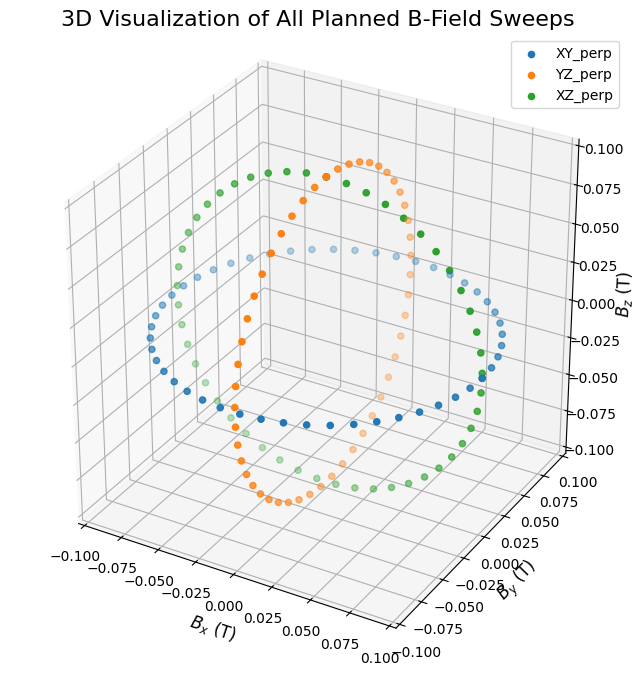

Plot displayed.


In [12]:
# ==============================================================================
# ## 3. Create the 3D Plot for Verification
# ==============================================================================
print("Generating 3D plot...")

# Create a figure and a 3D axes object
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points for each plane
for plane_name, config in sweep_definitions.items():
    # Unzip the list of (x, y, z) tuples into three separate lists

    points = config['points']
    if not points: continue # Skip if no points
    x_coords, y_coords, z_coords = zip(*points)
    
    # Create the scatter plot for the current plane
    ax.scatter(x_coords, y_coords, z_coords,  marker='o', label=plane_name)

# --- Add labels and titles for clarity ---
ax.set_xlabel('$B_x$ (T)', fontsize=12)
ax.set_ylabel('$B_y$ (T)', fontsize=12)
ax.set_zlabel('$B_z$ (T)', fontsize=12)
ax.set_title('3D Visualization of All Planned B-Field Sweeps', fontsize=16)

# --- Set axis limits and aspect ratio ---
ax.set_xlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_ylim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_zlim([-B_AMPLITUDE, B_AMPLITUDE])
ax.set_aspect('equal')  # Crucial for correct spherical appearance

# --- Add legend and grid ---
ax.legend()
ax.grid(True)

# --- Show the plot ---
plt.show()
print("Plot displayed.")

In [ ]:
config['points']

In [13]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: XY_perp ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW2\B0\B_sweep_XY_perp


XY_perp Sweep Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Ramping to target: (0.10, 0.00, 0.00) T ---
Ramping complete.
Check charge State...
Performing PLE scan...


XY_perp Sweep Progress:   2%|▏         | 1/50 [04:10<3:24:48, 250.80s/it]

PLE scan complete.
Calculated splitting: 20.57 MHz

--- Ramping to target: (0.10, 0.01, 0.00) T ---
Ramping complete.
Check charge State...
Performing PLE scan...


...

XY_perp Sweep Progress: 100%|██████████| 50/50 [48:09<00:00, 57.78s/it]


PLE scan complete.
Calculated splitting: 1005.56 MHz

✅ --- XY_perp Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: YZ_perp ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW2\B0\B_sweep_YZ_perp


YZ_perp Sweep Progress:   0%|          | 0/50 [00:00<?, ?it/s]


--- Ramping to target: (0.00, 0.00, 0.10) T ---


: 

In [6]:
import numpy as np

# Let's assume your function and inputs are the same
# (I've included the function here for a complete, runnable example)
def get_symmetry_vectors(angle_xy: float, angle_xz: float, angle_yz: float) -> tuple[np.ndarray, np.ndarray]:
    TOL = 1e-9
    if abs((angle_xz % 180) - 90) < TOL:
        vx = 0.0
        rad_yz = np.deg2rad(angle_yz)
        vy = np.cos(rad_yz)
        vz = np.sin(rad_yz)
        vector_aligned = np.array([vx, vy, vz])
    else:
        phi = np.deg2rad(angle_xy)
        rad_xz = np.deg2rad(angle_xz)
        cot_theta = np.tan(rad_xz) * np.cos(phi)
        sin_theta = 1.0 / np.sqrt(1 + cot_theta**2)
        cos_theta = cot_theta * sin_theta
        vx = sin_theta * np.cos(phi)
        vy = sin_theta * np.sin(phi)
        vz = cos_theta
        vector_aligned = np.array([vx, vy, vz])
    if abs(vector_aligned[0]) < 0.9:
        temp_vec = np.array([1.0, 0.0, 0.0])
    else:
        temp_vec = np.array([0.0, 1.0, 0.0])
    vector_perpendicular = np.cross(vector_aligned, temp_vec)
    vector_perpendicular /= np.linalg.norm(vector_perpendicular)
    return vector_aligned, vector_perpendicular

# --- Your original code ---
xy_proj_angle = -2.0
xz_proj_angle = 90.0
yz_proj_angle = 68.0

xy_proj_angle = -2
xz_proj_angle = 53
yz_proj_angle = 90.0 - 2

# Get the unit vector representing the direction
aligned_unit_vec, perp_unit_vec = get_symmetry_vectors(xy_proj_angle, xz_proj_angle, yz_proj_angle)

# --- NEW PART: Scaling the vector ---
# Define your desired B-field amplitude (e.g., 0.1 Tesla)
B_AMPLITUDE = 0.2 # Tesla

# Multiply the unit vector by the desired amplitude
b_field_vector = B_AMPLITUDE * aligned_unit_vec

print(f"Direction (Unit Vector): {np.round(aligned_unit_vec, 4)}")
print(f"B-Field Vector (0.1 T):  {np.round(b_field_vector, 4)}")

b_field_vector_perp = B_AMPLITUDE * perp_unit_vec
print(f"Direction (Unit Vector) Perp: {np.round(perp_unit_vec, 4)}")
print(f"B-Field Vector (0.1 T) Perp :  {np.round(b_field_vector_perp, 4)}")
# --- Verification ---
# You can verify the magnitude (norm) of the new vector
magnitude = np.linalg.norm(b_field_vector)
print(f"\nMagnitude of the final B-field vector: {magnitude:.4f} T")

Direction (Unit Vector): [ 0.6017 -0.021   0.7985]
B-Field Vector (0.1 T):  [ 0.1203 -0.0042  0.1597]
Direction (Unit Vector) Perp: [-0.      0.9997  0.0263]
B-Field Vector (0.1 T) Perp :  [-0.      0.1999  0.0053]

Magnitude of the final B-field vector: 0.2000 T


In [16]:
aligned_unit_vec

array([ 0.60168217, -0.0210112 ,  0.7984592 ])

In [ ]:
vector_perpendicular

In [ ]:
vector_magnet.ramp(field_target= [0.,0.1,-0.02])

In [9]:
vector_magnet.ramp(field_target= [0.0,0.0,0.0])

In [ ]:
vector_magnet

In [ ]:
vector_magnet.ramp(field_target= [0.0,0.093,-0.0375])

Defining defect frame of reference...
Normalized Defect Axis (z'): [ 0.602 -0.021  0.798]
Rotation matrix from Defect Frame -> Lab Frame created.
Generating B-field target points in the defect's frame...
Generating 3D plot of sweeps in the LAB FRAME...


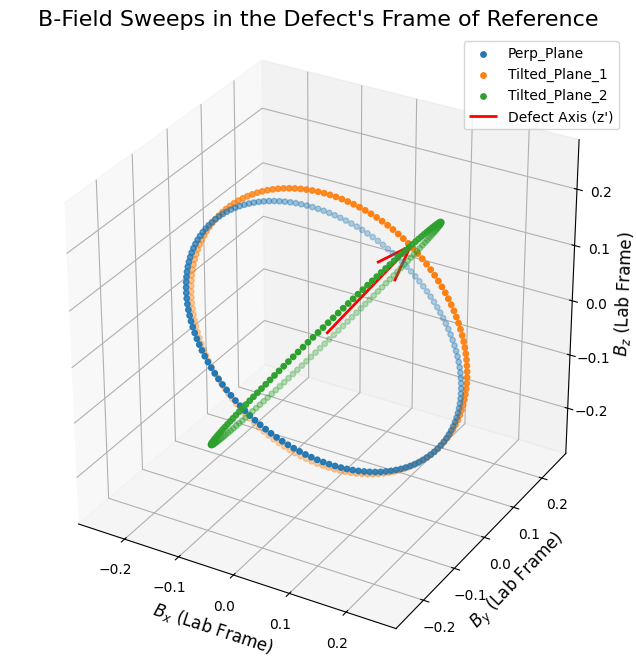

Plot displayed.


In [7]:
import os
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation

# --- Assume these hardware control objects and functions are defined elsewhere ---
# from your_instrument_library import vector_magnet, laser_scanner_logic
# from your_analysis_library import do_ple_scan, save_ple

# ==============================================================================
# ## 1. Configuration
# ==============================================================================
# Define the base directory for saving all measurement data
BASE_FOLDER = r'Z:\Vlad\heavyIV\158\170keV\MW\B2_perp_3'
B_AMPLITUDE = 0.25  # Tesla
NUM_STEPS = 150     # Number of points per sweep

# ==============================================================================
# ## 2. Define Defect Frame and Transformation
# ==============================================================================
print("Defining defect frame of reference...")

# ⬇️ ------------------ USER INPUT REQUIRED ------------------ ⬇️
# Define the defect's primary symmetry axis vector in the LAB FRAME.
# This vector must be measured or known beforehand.
# EXAMPLE: A defect axis pointing between X, Y, and Z.
DEFECT_AXIS = aligned_unit_vec #np.array([-0.0, .1124, 0.2782])  # Example vector in Tesla
# ⬆️ --------------------------------------------------------- ⬆️

# --- Normalize the defect axis to be a unit vector (our new z') ---
z_prime = DEFECT_AXIS / np.linalg.norm(DEFECT_AXIS)
print(f"Normalized Defect Axis (z'): {np.round(z_prime, 3)}")

# --- Create the other two orthogonal basis vectors (x' and y') ---
# This creates a full right-handed coordinate system (x', y', z').
# We use the Gram-Schmidt process, which is what Rotation.from_rotvec does internally.
# Find the rotation that maps the lab z-axis (0,0,1) to our defect z' axis.
align_rotation = Rotation.align_vectors(a=z_prime, b=[[0, 0, 1]])[0]

# Use this rotation to find where the lab x and y axes end up.
x_prime = align_rotation.apply([1, 0, 0])
y_prime = align_rotation.apply([0, 1, 0])

# The rotation matrix `R` transforms vectors from the DEFECT frame to the LAB frame.
# Its columns are the new basis vectors (x', y', z') expressed in lab coordinates.
R = np.column_stack([x_prime, y_prime, z_prime])
print("Rotation matrix from Defect Frame -> Lab Frame created.")


# ==============================================================================
# ## 3. Generate B-Field Target Points in the Defect Frame
# ==============================================================================
print("Generating B-field target points in the defect's frame...")
angles = np.linspace(0, 2 * np.pi, NUM_STEPS, endpoint=False)

# Define sweep points IN THE DEFECT'S COORDINATE SYSTEM (B_x', B_y', B_z')
# These are simple circles in the principal planes of the defect.
points_in_defect_frame = {
    # Sweep in the plane PERPENDICULAR to the defect axis (the x'-y' plane)
    'Perp_Plane': np.array([
        B_AMPLITUDE * np.cos(angles),  # B_x'
        B_AMPLITUDE * np.sin(angles),  # B_y'
        np.zeros(NUM_STEPS)            # B_z'
    ]).T,

    # Sweep in a plane CONTAINING the defect axis (the x'-z' plane)
    'Tilted_Plane_1': np.array([
        B_AMPLITUDE * np.cos(angles),  # B_x'
        np.zeros(NUM_STEPS),           # B_y'
        B_AMPLITUDE * np.sin(angles)   # B_z'
    ]).T,

    # Sweep in the other plane CONTAINING the defect axis (the y'-z' plane)
    'Tilted_Plane_2': np.array([
        np.zeros(NUM_STEPS),           # B_x'
        B_AMPLITUDE * np.cos(angles),  # B_y'
        B_AMPLITUDE * np.sin(angles)   # B_z'
    ]).T,
}

# --- Transform points to the Lab Frame and set up sweep definitions ---
sweep_definitions = {}
for plane_name, points_prime in points_in_defect_frame.items():
    # Use the rotation matrix R to convert all points to the lab frame
    # B_lab = R @ B_defect
    points_lab = (R @ points_prime.T).T

    sweep_definitions[plane_name] = {
        'points': list(map(tuple, points_lab)),
        'folder': os.path.join(BASE_FOLDER, f'B_sweep_{plane_name}')
    }

# ==============================================================================
# ## 4. Main Measurement Function (No changes needed here)
# ==============================================================================
def run_planar_sweep(plane_name: str, field_targets: list, output_folder: str):
    """
    Executes a full B-field sweep measurement for a given set of points.
    
    Args:
        plane_name (str): Name of the plane being swept (e.g., 'Perp_Plane').
        field_targets (list): A list of [Bx, By, Bz] target tuples in the LAB FRAME.
        output_folder (str): The full path to the folder where data will be saved.
    """
    print(f"\n--- 🚀 Starting Measurement for Plane: {plane_name} ---")
    
    # --- Create and verify destination folder ---
    if os.path.exists(output_folder):
        raise FileExistsError(f"The folder '{output_folder}' already exists. Please rename or delete it.")
    os.makedirs(output_folder)
    print(f"Created folder: {output_folder}")

    ple_splitting = []
    field_targets = np.array(field_targets)
    # --- Main Loop with Progress Bar ---
    for field_target in tqdm(field_targets, desc=f"{plane_name} Sweep Progress"):
        # print(f"\n--- Ramping to target: ({field_target[0]:.3f}, {field_target[1]:.3f}, {field_target[2]:.3f}) T ---")
        
        # NOTE: This part is unchanged. It assumes the existence of the hardware control functions.
        # 1. Ramp the field
        vector_magnet.ramp(field_target=field_target)
        while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
            time.sleep(2)
        # print("Ramping complete.")
        max_attempts = 10
        attempt = 0
       
        while attempt < max_attempts:
            fit = do_ple_scan(lines=1, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
            if fit.rsquared >= 0.1:
                # 5. Save Data
                tag = f"CHARGE_CHECK_target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
                save_ple(tag=tag, poi_name=None, folder_name=output_folder)
                break
            switch_combiner_interfuse.set_state(switch="GreenBF", state="On")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="Off")
            time.sleep(5)
            switch_combiner_interfuse.set_state(switch="GreenBF", state="Off")
            switch_combiner_interfuse.set_state(switch="ResonantBF", state="On")
            attempt += 1
        # 2. Perform PLE Scan
        # print("Performing PLE scan...")
        fit = do_ple_scan(lines=5, in_range=laser_scanner_logic.scan_ranges['a'], channel='APD1')
        
        # 3. Wait for Laser Scanner to be ready
        while laser_scanner_logic.module_state() == 'locked':
            time.sleep(0.5)
        # print("PLE scan complete.")

        # 4. Calculate Splitting
        delta = fit.params['center_2'].value - fit.params['center_1'].value
        ple_splitting.append(delta)
        # print(f"Calculated splitting: {delta:.2f} MHz")

        # 5. Save Data
        tag = f"target_{field_target[0]:.4f}_{field_target[1]:.4f}_{field_target[2]:.4f}_T"
        save_ple(tag=tag, poi_name=None, folder_name=output_folder)
        pass # Placeholder for the loop to run without hardware
        
    print(f"\n✅ --- {plane_name} Measurement Complete! ---")
    return ple_splitting
    
# ==============================================================================
# ## 5. Create the 3D Plot for Verification
# ==============================================================================
print("Generating 3D plot of sweeps in the LAB FRAME...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points for each plane
for plane_name, config in sweep_definitions.items():
    points = np.array(config['points'])
    if points.size == 0: continue
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], marker='o', label=plane_name, s=15)

# --- Add the defect axis vector to the plot for visualization ---
ax.quiver(0, 0, 0, 
          B_AMPLITUDE * z_prime[0], B_AMPLITUDE * z_prime[1], B_AMPLITUDE * z_prime[2], 
          color='r', label='Defect Axis (z\')', length=B_AMPLITUDE, normalize=True, linewidth=2)

# --- Add labels and titles for clarity ---
ax.set_xlabel('$B_x$ (Lab Frame)', fontsize=12)
ax.set_ylabel('$B_y$ (Lab Frame)', fontsize=12)
ax.set_zlabel('$B_z$ (Lab Frame)', fontsize=12)
ax.set_title('B-Field Sweeps in the Defect\'s Frame of Reference', fontsize=16)

# --- Set axis limits and aspect ratio ---
lim = B_AMPLITUDE * 1.1
ax.set_xlim([-lim, lim])
ax.set_ylim([-lim, lim])
ax.set_zlim([-lim, lim])
ax.set_aspect('equal')

ax.legend()
ax.grid(True)
plt.show()
print("Plot displayed.")



In [8]:

# ==============================================================================
# ## 4. Execute All Measurements
# ==============================================================================
all_results = {}

try:
    # --- Initial Magnet Check ---
    print("Waiting for initial vector magnet state...")
    while list(vector_magnet.get_ramping_state()) != [2, 2, 2]:
        print(f"Current ramping state: {vector_magnet.get_ramping_state()} - Waiting...")
        time.sleep(30)
    print("✅ Vector magnet is ready to begin the measurement sequence.")

    # --- Loop through and run each defined sweep ---
    for plane, config in sweep_definitions.items():
       
        results = run_planar_sweep(
            plane_name=plane,
            field_targets=config['points'],
            output_folder=config['folder']
        )
        all_results[plane] = results

except (Exception, KeyboardInterrupt) as e:
    print(f"\n\n❌ An error occurred or the script was interrupted: {e}")
    print("Measurement sequence aborted.")

finally:
    # --- Final Summary ---
    print("\n\n" + "="*50)
    print("--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---")
    print("="*50)
    if not all_results:
        print("No measurements were completed.")
    else:
        for plane, splits in all_results.items():
            print(f"\nResults for {plane} Plane:")
            # print(f"  - Data saved in: {sweep_definitions[plane]['folder']}")
            # print(f"  - Final PLE Splitting Values (MHz): {np.round(splits, 2).tolist()}")
    print("\n--- Script finished. ---")

Waiting for initial vector magnet state...
✅ Vector magnet is ready to begin the measurement sequence.

--- 🚀 Starting Measurement for Plane: Perp_Plane ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW\B2_perp_3\B_sweep_Perp_Plane


Perp_Plane Sweep Progress: 100%|██████████| 150/150 [2:17:59<00:00, 55.20s/it]  



✅ --- Perp_Plane Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: Tilted_Plane_1 ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW\B2_perp_3\B_sweep_Tilted_Plane_1


Tilted_Plane_1 Sweep Progress: 100%|██████████| 150/150 [2:11:09<00:00, 52.46s/it] 



✅ --- Tilted_Plane_1 Measurement Complete! ---

--- 🚀 Starting Measurement for Plane: Tilted_Plane_2 ---
Created folder: Z:\Vlad\heavyIV\158\170keV\MW\B2_perp_3\B_sweep_Tilted_Plane_2


Tilted_Plane_2 Sweep Progress: 100%|██████████| 150/150 [2:14:15<00:00, 53.70s/it] 


✅ --- Tilted_Plane_2 Measurement Complete! ---


--- ✨ FINAL MEASUREMENT SUMMARY ✨ ---

Results for Perp_Plane Plane:

Results for Tilted_Plane_1 Plane:

Results for Tilted_Plane_2 Plane:

--- Script finished. ---
